In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
# Load the three raw datasets from the data directory:
#   train.csv            — hourly meter readings per building
#   building_metadata.csv — static building characteristics (size, use, etc.)
#   weather_train.csv    — hourly weather observations per site
data = "data"
train = pd.read_csv(os.path.join(data, "train.csv"))
building = pd.read_csv(os.path.join(data, "building_metadata.csv"))
weather = pd.read_csv(os.path.join(data, "weather_train.csv"))

# Parse timestamp strings to datetime objects for time-based operations
train["timestamp"] = pd.to_datetime(train["timestamp"])
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

print(train.shape)
print(building.shape)
print(weather.shape)

(20216100, 4)
(1449, 6)
(139773, 9)


In [ ]:
# Inspect the first few rows of the training data
# Columns: building_id, meter (0-3), timestamp, meter_reading
train.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0
3,3,0,2016-01-01,0.0
4,4,0,2016-01-01,0.0


In [ ]:
# Inspect the first few rows of the building metadata
# Columns: building_id, site_id, primary_use, square_feet, year_built, floor_count
building.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [ ]:
# Inspect the first few rows of the weather data
# Columns: site_id, timestamp, air_temperature, cloud_coverage, etc.
weather.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
# Display column dtypes, non-null counts, and memory usage for the training set
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype         
---  ------         -----         
 0   building_id    int64         
 1   meter          int64         
 2   timestamp      datetime64[ns]
 3   meter_reading  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 616.9 MB


In [ ]:
# Display column dtypes and non-null counts for the building metadata
building.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   object 
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 68.1+ KB


In [ ]:
# Display column dtypes and non-null counts for the weather data
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139773 entries, 0 to 139772
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   site_id             139773 non-null  int64         
 1   timestamp           139773 non-null  datetime64[ns]
 2   air_temperature     139718 non-null  float64       
 3   cloud_coverage      70600 non-null   float64       
 4   dew_temperature     139660 non-null  float64       
 5   precip_depth_1_hr   89484 non-null   float64       
 6   sea_level_pressure  129155 non-null  float64       
 7   wind_direction      133505 non-null  float64       
 8   wind_speed          139469 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 9.6 MB


In [ ]:
# Check null counts across all three datasets before any imputation
# This guides which columns need filling and what strategy to use
print("Train missing values:")
print(train.isna().sum())
print("\n")
print("Building missing values:")
print(building.isna().sum())
print("\n")
print("Weather missing values:")
print(weather.isna().sum())

Train missing values:
building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64


Building missing values:
site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64


Weather missing values:
site_id                   0
timestamp                 0
air_temperature          55
cloud_coverage        69173
dew_temperature         113
precip_depth_1_hr     50289
sea_level_pressure    10618
wind_direction         6268
wind_speed              304
dtype: int64


In [ ]:
# Impute missing year_built and floor_count with their respective column medians
# Encode primary_use as a numeric category code so tree/linear models can use it
building = building.copy()
building["year_built"] = building["year_built"].fillna(building["year_built"].median())
building["floor_count"] = building["floor_count"].fillna(building["floor_count"].median())
building["primary_use"] = building["primary_use"].astype("category")
building["primary_use_id"] = building["primary_use"].cat.codes

In [176]:
weather = weather.copy()
weather = weather.sort_values(["site_id", "timestamp"])
weather_columns = ["air_temperature", "cloud_coverage", "dew_temperature", "precip_depth_1_hr", "sea_level_pressure", "wind_direction", "wind_speed"]
for i in weather_columns:
    #use linear interpolation to fill missing values (meaning the value is estimated based on the values before and after it in the same site_id group)
    weather[i] = weather.groupby("site_id")[i].transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
    #fill the rest of the missing values with the median
    weather[i] = weather[i].fillna(weather[i].median())

In [ ]:
# Confirm all weather nulls are resolved after interpolation and median fill
weather.isna().sum()

site_id               0
timestamp             0
air_temperature       0
cloud_coverage        0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64

In [ ]:
# Left-join the training data with building metadata on building_id
# Every meter reading now carries the building's static attributes
df = train.merge(building, on="building_id", how="left")
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,primary_use_id
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,3.0,0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,3.0,0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,3.0,0
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,3.0,0
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,3.0,0


In [ ]:
# Attach weather readings to each row by matching site_id and timestamp
# A left join preserves all meter readings even if weather is missing for that hour
df = df.merge(weather, on=["site_id", "timestamp"], how="left")
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,primary_use_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,3.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,3.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,3.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,3.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,3.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0


In [ ]:
# List all columns in the fully merged dataframe
df.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'primary_use_id', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed'],
      dtype='object')

In [ ]:
# Check the total number of rows and columns after the full merge
df.shape

(20216100, 17)

In [ ]:
# Identify any columns still carrying null values after the merge
# (expected: some weather columns where site/timestamp had no match)
df.isna().sum()

building_id               0
meter                     0
timestamp                 0
meter_reading             0
site_id                   0
primary_use               0
square_feet               0
year_built                0
floor_count               0
primary_use_id            0
air_temperature       90495
cloud_coverage        90495
dew_temperature       90495
precip_depth_1_hr     90495
sea_level_pressure    90495
wind_direction        90495
wind_speed            90495
dtype: int64

In [ ]:
# Fill remaining numeric NaN values with column medians
# Handles edge-case gaps left after interpolation / join mismatches
df = df.fillna(df.median(numeric_only=True))
df.isna().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
primary_use           0
square_feet           0
year_built            0
floor_count           0
primary_use_id        0
air_temperature       0
cloud_coverage        0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64

In [ ]:
# Verify the timestamp column looks correct after the merge
print(df["timestamp"])

0          2016-01-01 00:00:00
1          2016-01-01 00:00:00
2          2016-01-01 00:00:00
3          2016-01-01 00:00:00
4          2016-01-01 00:00:00
                   ...        
20216095   2016-12-31 23:00:00
20216096   2016-12-31 23:00:00
20216097   2016-12-31 23:00:00
20216098   2016-12-31 23:00:00
20216099   2016-12-31 23:00:00
Name: timestamp, Length: 20216100, dtype: datetime64[ns]


In [ ]:
# Extract raw calendar components from the timestamp
# These serve as the basis for cyclical time features added in the next cell
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["dayofyear"] = df["timestamp"].dt.dayofyear

In [ ]:
# Encode cyclic time features using sin/cos pairs so the model correctly
# perceives continuity at boundaries (hour 23->0, day 6->0, month 12->1).
# A plain integer would create an artificial "jump" at those wrap-around points.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
# Binary flag: 1 for Saturday (5) or Sunday (6), 0 otherwise
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

In [ ]:
# Summarise the distribution of raw meter readings to spot outliers and anomalies
# (e.g., negative values or extreme spikes that need handling)
print(df["meter_reading"].describe())

count    2.021610e+07
mean     2.117121e+03
std      1.532356e+05
min      0.000000e+00
25%      1.830000e+01
50%      7.877500e+01
75%      2.679840e+02
max      2.190470e+07
Name: meter_reading, dtype: float64


In [ ]:
# Drop rows with negative meter readings — physically impossible values
df = df[df["meter_reading"] >= 0]

In [183]:
#log(1 + x)
#it deals with elements that are equal to 0
#it also reduces the impact of outliers by compressing the range of values
df["target"] = np.log1p(df["meter_reading"])
df["target"].describe()

count    2.021610e+07
mean     4.145766e+00
std      2.146220e+00
min      0.000000e+00
25%      2.960105e+00
50%      4.379210e+00
75%      5.594652e+00
max      1.690221e+01
Name: target, dtype: float64

In [ ]:
# Site 0, electricity meter (meter=0) readings before 2016-05-21 are known to be
# faulty — the meters were not yet calibrated at that site. Flag them for removal.
bad_values = ((df["site_id"] == 0) & (df["meter"] == 0) & (df["timestamp"] < "2016-05-21"))
print("Rows to remove:", bad_values.sum())

Rows to remove: 348560


In [ ]:
# Remove the flagged faulty readings from the dataset
df = df[~bad_values]

In [ ]:
# Confirm the number of rows remaining after all cleaning steps
print(df.shape)

(19867540, 29)


In [ ]:
# Review the final set of columns before selecting model input features
df.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'primary_use', 'square_feet', 'year_built', 'floor_count',
       'primary_use_id', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'hour', 'dayofweek', 'month',
       'dayofyear', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'is_weekend', 'target'],
      dtype='object')

In [189]:
input_features = [
#Building / meter
"building_id",
"meter",
"site_id",
"square_feet",
"primary_use_id",
"year_built",
"floor_count",
    
    
#Weather
"air_temperature",
"cloud_coverage",
"dew_temperature",
"precip_depth_1_hr",
"sea_level_pressure",
"wind_direction",
"wind_speed",    
    
#Time
"hour_sin",
"hour_cos",
"month_sin",
"month_cos",
"dayofweek",
"is_weekend"    

]

#we didn't include
#1) meter_reading
#2) primary_use
#3) timestamp
#as the input features 1) would leak the target variable, 
#2) is already encoded in primary_use_id, 
#and 3) is not directly useful since we're using sin/cos transformations of the time features instead of the raw timestamp

target = "target"


In [ ]:
# Slice the merged dataframe to only the columns needed for modelling
# timestamp is kept for chronological ordering but is not a model input
model_df = df[["timestamp"] + input_features + [target]].copy()
model_df.head()

,timestamp,building_id,meter,site_id,square_feet,primary_use_id,year_built,floor_count,air_temperature,cloud_coverage,...,sea_level_pressure,wind_direction,wind_speed,hour_sin,hour_cos,month_sin,month_cos,dayofweek,is_weekend,target
103,2016-01-01,105,0,1,50623,0,1970.0,5.0,3.8,0.0,...,1020.9,240.0,3.1,0.0,1.0,0.5,0.866025,4,0,3.190624
104,2016-01-01,106,0,1,5374,0,1970.0,4.0,3.8,0.0,...,1020.9,240.0,3.1,0.0,1.0,0.5,0.866025,4,0,0.318163
105,2016-01-01,106,3,1,5374,0,1970.0,4.0,3.8,0.0,...,1020.9,240.0,3.1,0.0,1.0,0.5,0.866025,4,0,0.000000
106,2016-01-01,107,0,1,97532,0,2005.0,10.0,3.8,0.0,...,1020.9,240.0,3.1,0.0,1.0,0.5,0.866025,4,0,5.171529
107,2016-01-01,108,0,1,81580,0,1913.0,5.0,3.8,0.0,...,1020.9,240.0,3.1,0.0,1.0,0.5,0.866025,4,0,4.524668


In [191]:
#yeah we're not training it on all 20 million rows
site_counts = model_df["site_id"].value_counts()
min_site_id = site_counts.idxmin()
min_count = site_counts.min()
print(f"Fewest rows: Site ID {min_site_id} (Count: {min_count})")

subset_df = model_df[model_df["site_id"] == min_site_id].copy()

Fewest rows: Site ID 11 (Count: 119459)


In [ ]:
# Preview the smallest-site subset that will be used for all model training
subset_df.head()

,timestamp,building_id,meter,site_id,square_feet,primary_use_id,year_built,floor_count,air_temperature,cloud_coverage,...,sea_level_pressure,wind_direction,wind_speed,hour_sin,hour_cos,month_sin,month_cos,dayofweek,is_weekend,target
1423,2016-01-01,1029,0,11,152559,0,1970.0,3.0,-1.8,2.0,...,1016.0,280.0,1.5,0.0,1.0,0.5,0.866025,4,0,5.509388
1424,2016-01-01,1029,3,11,152559,0,1970.0,3.0,-1.8,2.0,...,1016.0,280.0,1.5,0.0,1.0,0.5,0.866025,4,0,4.955327
1425,2016-01-01,1030,0,11,68030,0,1970.0,3.0,-1.8,2.0,...,1016.0,280.0,1.5,0.0,1.0,0.5,0.866025,4,0,3.931826
1426,2016-01-01,1030,1,11,68030,0,1970.0,3.0,-1.8,2.0,...,1016.0,280.0,1.5,0.0,1.0,0.5,0.866025,4,0,0.000000
1427,2016-01-01,1030,3,11,68030,0,1970.0,3.0,-1.8,2.0,...,1016.0,280.0,1.5,0.0,1.0,0.5,0.866025,4,0,5.645984


In [192]:
from sklearn.preprocessing import StandardScaler

features_that_we_do_not_want_to_scale = [
    "timestamp",
    "target",
    "building_id",
    "meter",
    "site_id",
    "primary_use_id",
    "is_weekend"
]

continuous_cols = [
    "square_feet",
    "year_built",
    "floor_count",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "dayofweek"
]
#the reason why we scale the continuous features is because they are on different scales 
#for ex: square_feet can be in the thousands while air_temperature is usually between -20 and 40
#converge faster and perform better.

scaler = StandardScaler()
subset_df[continuous_cols] = scaler.fit_transform(subset_df[continuous_cols])
subset_df.reset_index(drop=True, inplace=True)
subset_df.head()

,timestamp,building_id,meter,site_id,square_feet,primary_use_id,year_built,floor_count,air_temperature,cloud_coverage,...,sea_level_pressure,wind_direction,wind_speed,hour_sin,hour_cos,month_sin,month_cos,dayofweek,is_weekend,target
0,2016-01-01,1029,0,11,1.721785,0,0.0,0.0,-0.801092,0.0,...,0.087273,0.69971,-0.980903,0.0,1.0,0.5,0.866025,0.499142,0,5.509388
1,2016-01-01,1029,3,11,1.721785,0,0.0,0.0,-0.801092,0.0,...,0.087273,0.69971,-0.980903,0.0,1.0,0.5,0.866025,0.499142,0,4.955327
2,2016-01-01,1030,0,11,-1.140223,0,0.0,0.0,-0.801092,0.0,...,0.087273,0.69971,-0.980903,0.0,1.0,0.5,0.866025,0.499142,0,3.931826
3,2016-01-01,1030,1,11,-1.140223,0,0.0,0.0,-0.801092,0.0,...,0.087273,0.69971,-0.980903,0.0,1.0,0.5,0.866025,0.499142,0,0.000000
4,2016-01-01,1030,3,11,-1.140223,0,0.0,0.0,-0.801092,0.0,...,0.087273,0.69971,-0.980903,0.0,1.0,0.5,0.866025,0.499142,0,5.645984


In [ ]:
# Utility to compute MAE and RMSE for any model's predictions on the log-scale target
# Returns a dict so results from multiple models can be collected and compared in a table
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    
    return {"Model": name, "MAE": mae, "RMSE": rmse}

In [201]:
#test it out on baseline models
#1) Finite Differencing
#2) Linear Regression
#3) ARIMA
baseline_df = subset_df.copy()
baseline_df = baseline_df.sort_values(["building_id", "meter", "timestamp"])

In [202]:
#Previous hour
baseline_df["target_lag_1"] = baseline_df.groupby(["building_id", "meter"])["target"].shift(1)
#Two hours ago
baseline_df["target_lag_2"] = baseline_df.groupby(["building_id", "meter"])["target"].shift(2)

#Same hour yesterday
baseline_df["target_lag_24"] = baseline_df.groupby(
    ["building_id", "meter"]
)["target"].shift(24)

#Same hour last week
baseline_df["target_lag_168"] = baseline_df.groupby(
    ["building_id", "meter"]
)["target"].shift(168)

In [203]:
#finite differencing = previous value + (previous value - value before previous)
baseline_df["finite_diff_pred"] = (baseline_df["target_lag_1"] + (baseline_df["target_lag_1"] - baseline_df["target_lag_2"]))

In [ ]:
# Drop rows where lag features are NaN (the first N rows of each series have no history)
# Reset the index so it stays contiguous after the drop
baseline_df = baseline_df.dropna()
baseline_df = baseline_df.reset_index(drop=True)
baseline_df.head()

,timestamp,building_id,meter,site_id,square_feet,primary_use_id,year_built,floor_count,air_temperature,cloud_coverage,...,month_sin,month_cos,dayofweek,is_weekend,target,target_lag_1,target_lag_2,target_lag_24,target_lag_168,finite_diff_pred
0,2016-01-21 08:00:00,1028,0,11,-0.687876,0,0.0,0.0,-1.583609,0.0,...,0.5,0.866025,-0.002068,0,5.010635,4.804021,4.634729,4.882802,4.189655,4.973313
1,2016-01-21 09:00:00,1028,0,11,-0.687876,0,0.0,0.0,-1.616557,0.0,...,0.5,0.866025,-0.002068,0,5.043425,5.010635,4.804021,4.990433,4.919981,5.217250
2,2016-01-21 10:00:00,1028,0,11,-0.687876,0,0.0,0.0,-1.674216,0.0,...,0.5,0.866025,-0.002068,0,5.075174,5.043425,5.010635,5.099866,4.941642,5.076215
3,2016-01-21 11:00:00,1028,0,11,-0.687876,0,0.0,0.0,-1.698927,0.0,...,0.5,0.866025,-0.002068,0,5.117994,5.075174,5.043425,5.093750,5.010635,5.106923
4,2016-01-21 12:00:00,1028,0,11,-0.687876,0,0.0,0.0,-1.764824,0.0,...,0.5,0.866025,-0.002068,0,5.111988,5.117994,5.075174,5.147494,5.023881,5.160814


In [ ]:
# Chronological 80/20 split using the 80th-percentile timestamp as the boundary
# Time-based splitting is critical — a random split would leak future data into training
split_time = baseline_df["timestamp"].quantile(0.8)
train_base_df = baseline_df[baseline_df["timestamp"] <= split_time].copy()
val_base_df = baseline_df[baseline_df["timestamp"] > split_time].copy()

print("Split time:", split_time)
print("Train shape:", train_base_df.shape)
print("Validation shape:", val_base_df.shape)

Split time: 2016-10-22 10:00:00
Train shape: (93686, 27)
Validation shape: (23421, 27)


In [ ]:
# Evaluate finite differencing on the full dataset and store the result
# (finite differencing is a naive extrapolation baseline, so no train/val needed)
results = []
results.append(evaluate_model("Finite Differencing", baseline_df["target"], baseline_df["finite_diff_pred"]))

Finite Differencing
MAE: 0.1732
RMSE: 0.5709


In [ ]:
# Feature set for linear regression — includes building attributes, weather conditions,
# cyclic time features, and autoregressive lag terms (previous hour, day, week)
linear_features = [
    # Building features
    "square_feet",
    "year_built",
    "floor_count",
    
    # Weather features
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    
    # Time features
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek",
    "is_weekend",
    
    # Lag features (autoregressive terms)
    "target_lag_1",
    "target_lag_2",
    "target_lag_24",
    "target_lag_168"
]

X_train_base = train_base_df[linear_features]
y_train_base = train_base_df["target"]

X_val_base = val_base_df[linear_features]
y_val_base = val_base_df["target"]

print("X_train:", X_train_base.shape)
print("y_train:", y_train_base.shape)
print("X_val:", X_val_base.shape)
print("y_val:", y_val_base.shape)

X_train: (93686, 20)
y_train: (93686,)
X_val: (23421, 20)
y_val: (23421,)


In [ ]:
# Train an OLS linear regression model and evaluate it on the validation set
# Linear regression serves as a stronger baseline than finite differencing
# because it can exploit building attributes and weather features simultaneously
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_base, y_train_base)
y_pred_linear = linear_model.predict(X_val_base)

results.append(evaluate_model("Linear Regression", y_val_base, y_pred_linear))

Linear Regression
MAE: 0.0955
RMSE: 0.2588


In [209]:
#ARIMA
#Here it's used on a single building and meter combination to predict the target variable based on its own past values

#ARIMA is univariate so it only uses the past values of the target variable to make predictions
#it doesn't use any of the other features in the dataset

#0 = Electricity
#1 = Chilled water
#2 = Steam
#3 = Hot water

first_building = subset_df["building_id"].iloc[0]
first_meter = subset_df["meter"].iloc[0]

one_series = subset_df[(subset_df["building_id"] == first_building) & (subset_df["meter"] == first_meter)].copy()
one_series = one_series.sort_values("timestamp")

print("Building:", first_building)
print("Meter:", first_meter)
print("Series length:", len(one_series))

Building: 1029
Meter: 0
Series length: 8773


In [ ]:
# Extract the raw target values for the single building/meter series chosen above
# and perform an 80/20 chronological split for ARIMA training and evaluation
from statsmodels.tsa.arima.model import ARIMA

series_values = one_series["target"].values
split_idx_arima = int(len(series_values) * 0.8)

train_arima = series_values[:split_idx_arima]
val_arima = series_values[split_idx_arima:]

print("ARIMA train length:", len(train_arima))
print("ARIMA validation length:", len(val_arima))

ARIMA train length: 7018
ARIMA validation length: 1755


In [211]:
#ARIMA(p, d, q) where:
#p = number of autoregressive terms (lags of the target variable)
#d = number of differences needed to make the series stationary
#q = number of lagged forecast errors in the prediction equation

arima_model = ARIMA(train_arima, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(val_arima))

In [ ]:
# Add ARIMA validation-set results to the shared baseline results list
results.append(evaluate_model("ARIMA", val_arima, arima_pred))

ARIMA
MAE: 0.1573
RMSE: 0.1848


In [213]:
results_df = pd.DataFrame(results)
results_df

#it's notewrothy that the ARIMA model is only trained on a single building and meter combination


,Model,MAE,RMSE
0,Finite Differencing,0.173202,0.570875
1,Linear Regression,0.095513,0.258790
2,ARIMA,0.157347,0.184776


In [219]:
#LSTM
input_features = [
    #Building / meter
    "building_id",
    "meter",
    "site_id",
    "square_feet",
    "primary_use_id",
    "year_built",
    "floor_count",
    
    #Weather
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",    
    
    #Time
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek",
    "is_weekend"    
]

target = "target"

In [ ]:
# Sliding-window sequence builder for time-series deep learning models.
# For each building/meter pair (treated as an independent time series),
# produces overlapping windows of length `window_size` as input X,
# with the time step immediately after each window as the label y.
def create_sequences(df, input_features, target, window_size):
    X_list = []
    y_list = []
    
    # Each building/meter pair is its own time series
    groups = df.groupby(["building_id", "meter"])

    for (building_id, meter), group in groups:
        group = group.sort_values("timestamp")
        
        X_values = group[input_features].values.astype("float32")
        y_values = group[target].values.astype("float32")
        
        # Skip series too short to produce even one complete window
        if len(group) <= window_size:
            continue
        
        for i in range(len(group) - window_size):
            X_list.append(X_values[i:i + window_size])
            y_list.append(y_values[i + window_size])
    
    X = np.array(X_list, dtype="float32")
    y = np.array(y_list, dtype="float32")
    
    return X, y

In [ ]:
# Build overlapping 24-hour input windows from the subset.
# Each window of 24 consecutive hours predicts the meter reading one step ahead.
X, y = create_sequences(subset_df, input_features=input_features, target=target, window_size = 24)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119123, 24, 20)
y shape: (119123,)


In [ ]:
# Chronological 80/20 split of the sequence arrays.
# The first 80% of sequences go to training, the last 20% to validation.
# No shuffling here — order must be preserved to avoid data leakage.
split_idx = int(len(X) * 0.8)
X_train = X[:split_idx]
y_train = y[:split_idx]
X_val = X[split_idx:]
y_val = y[split_idx:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (95298, 24, 20)
y_train: (95298,)
X_val: (23825, 24, 20)
y_val: (23825,)


In [ ]:
# PyTorch Dataset wrapper that converts NumPy arrays to float32 tensors.
# y is unsqueezed from shape [N] to [N, 1] to match the model's scalar output.
import torch
from torch.utils.data import Dataset, DataLoader

class EnergySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # Add output dimension so shapes align with nn.Linear output: [N] -> [N, 1]
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
# Wrap datasets in DataLoaders for batched, optionally-shuffled iteration.
# shuffle=True on the training loader reduces gradient variance across batches.
# shuffle=False on the validation loader keeps evaluation order deterministic.
train_dataset = EnergySequenceDataset(X_train, y_train)
val_dataset = EnergySequenceDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

# Quick sanity check: verify tensor shapes for one batch
batch_X, batch_y = next(iter(train_loader))

print("Batch X:", batch_X.shape)
print("Batch y:", batch_y.shape)

Batch X: torch.Size([64, 24, 20])
Batch y: torch.Size([64, 1])


In [ ]:
# Two-layer LSTM followed by a fully-connected regression head.
# The LSTM captures sequential dependencies across the 24-hour input window.
# Only the hidden state at the final time step is used to predict the next hour.
import torch.nn as nn

class LSTMForecastModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMForecastModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # expects input shape [batch, seq_len, features]
            dropout=dropout         # applied between LSTM layers to reduce overfitting
        )
        
        # Maps the final hidden state (size=hidden_size) to a single scalar prediction
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: [batch_size, sequence_length, input_size]
        lstm_out, _ = self.lstm(x)
        
        # Use final time step's output as the summary of the whole sequence
        last_output = lstm_out[:, -1, :]
        
        prediction = self.fc(last_output)
        
        return prediction

In [ ]:
# Select GPU if available, otherwise fall back to CPU
# input_size is derived from the number of features in the training data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[2]
lstm_model = LSTMForecastModel(
    input_size=input_size,
    hidden_size=64, num_layers=2, dropout=0.2).to(device)

print(lstm_model)
print("Using device:", device)

LSTMForecastModel(
  (lstm): LSTM(20, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Using device: cpu


In [ ]:
# MSE loss is standard for regression tasks; Adam adapts the learning rate per parameter
# lr=0.001 is a common starting point — reduce if training loss oscillates
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [ ]:
# Full training loop: iterates for `epochs` passes over the training batches,
# computing MSE loss and updating weights via backpropagation each step.
# Validation loss is tracked every epoch to monitor generalisation.
def train_lstm_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()           # Clear accumulated gradients
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            loss.backward()                 # Compute gradients via backprop
            optimizer.step()               # Update model weights
            
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation pass — no gradient computation needed
        model.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f}"
        )
    
    return train_losses, val_losses

In [ ]:
# Train the LSTM for 10 epochs; loss histories are captured for the learning-curve plot
lstm_train_losses, lstm_val_losses = train_lstm_model(
    lstm_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
)

Epoch [1/10] Train Loss: 5.3782 Val Loss: 6.3245
Epoch [2/10] Train Loss: 5.2754 Val Loss: 6.4157
Epoch [3/10] Train Loss: 5.2718 Val Loss: 6.4309
Epoch [4/10] Train Loss: 5.2691 Val Loss: 6.3921
Epoch [5/10] Train Loss: 5.2686 Val Loss: 6.4528
Epoch [6/10] Train Loss: 5.2672 Val Loss: 6.3568
Epoch [7/10] Train Loss: 5.2726 Val Loss: 6.3512
Epoch [8/10] Train Loss: 5.2749 Val Loss: 6.3059
Epoch [9/10] Train Loss: 5.2756 Val Loss: 6.3304
Epoch [10/10] Train Loss: 5.2712 Val Loss: 6.3255


In [ ]:
# Generic evaluation function for any trained PyTorch regression model.
# Runs inference over the full validation DataLoader in no_grad mode,
# collects all predictions and targets, then reports MAE and RMSE
# (same metrics as evaluate_model, so results are directly comparable).
def evaluate_deep_model(model, val_loader, model_name):
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            predictions = model(batch_X).cpu().numpy().flatten()
            targets = batch_y.numpy().flatten()
            
            all_preds.extend(predictions)
            all_targets.extend(targets)
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    print(model_name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }

In [ ]:
# Evaluate the trained LSTM on the validation set and store the results
lstm_results = []

lstm_results.append(
    evaluate_deep_model(
        lstm_model,
        val_loader,
        "LSTM"
    )
)

lstm_results_df = pd.DataFrame(lstm_results)

lstm_results_df

LSTM
MAE: 2.3525
RMSE: 2.5164


,Model,MAE,RMSE
0,LSTM,2.352505,2.516392


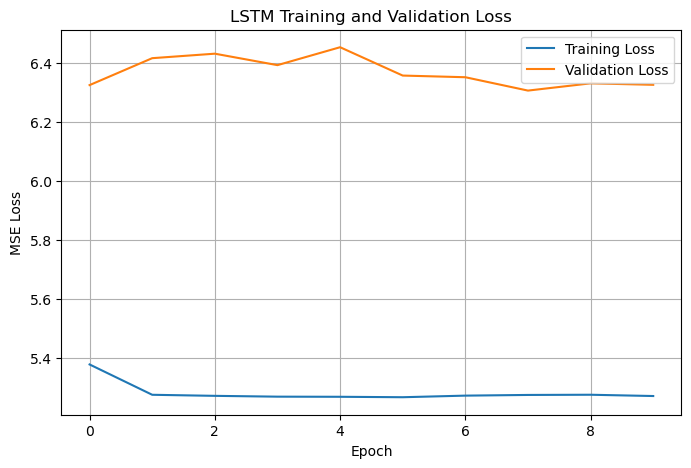

In [ ]:
# Plot LSTM training vs. validation loss to inspect learning dynamics.
# A converging gap between train and val loss indicates healthy generalisation;
# a growing gap signals overfitting.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(lstm_train_losses, label="Training Loss")
plt.plot(lstm_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Sinusoidal positional encoding as introduced in "Attention Is All You Need".
# Injects position information into token embeddings so the Transformer
# can exploit the sequential order of time steps (it has no built-in notion of order).
# Even-indexed dimensions use sine; odd-indexed dimensions use cosine.
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        
        # Build a (max_len, d_model) matrix of fixed positional encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        
        # Exponentially spaced frequency terms — one pair per embedding dimension
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        
        pe[:, 0::2] = torch.sin(position * div_term)   # even dims: sine
        pe[:, 1::2] = torch.cos(position * div_term)   # odd dims:  cosine
        
        # Add batch dimension: (max_len, d_model) -> (1, max_len, d_model)
        pe = pe.unsqueeze(0)
        
        # Register as a buffer — moves with the model but is not a trainable parameter
        self.register_buffer("pe", pe)
    
    def forward(self, x):
        seq_len = x.size(1)
        # Add positional encoding to input embeddings (broadcasts over the batch)
        return x + self.pe[:, :seq_len, :]

In [ ]:
# Transformer encoder-based model for single-step energy consumption forecasting.
# Architecture pipeline:
#   1. Linear projection  — maps raw input features to d_model embedding dimensions
#   2. Positional encoding — injects temporal order information into embeddings
#   3. Transformer encoder — stacked self-attention + feed-forward layers to capture
#                            long-range dependencies across the 24-hour input window
#   4. FC regression head  — projects the final time step's representation to a scalar
class TransformerForecastModel(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ):
        super(TransformerForecastModel, self).__init__()
        
        # Project raw input features into the transformer's embedding space
        self.input_projection = nn.Linear(input_size, d_model)
        
        self.positional_encoding = PositionalEncoding(
            d_model=d_model
        )
        
        # A single encoder layer consists of multi-head self-attention
        # followed by a position-wise feed-forward sublayer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,                    # number of parallel attention heads
            dim_feedforward=dim_feedforward, # width of the inner feed-forward layer
            dropout=dropout,
            batch_first=True
        )
        
        # Stack num_layers encoder layers
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        # Regression head: collapse d_model dimensions to a single predicted value
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x shape: [batch_size, sequence_length, input_size]
        
        # Step 1: project features to embedding space
        x = self.input_projection(x)
        
        # Step 2: add positional encoding
        x = self.positional_encoding(x)
        
        # Step 3: pass through transformer encoder stack
        transformer_out = self.transformer_encoder(x)
        
        # Step 4: use the final time step's output for next-hour prediction
        last_output = transformer_out[:, -1, :]
        
        prediction = self.fc(last_output)
        
        return prediction

In [ ]:
# Instantiate the Transformer with the same input dimensionality as the LSTM
# so results are directly comparable. nhead=4 requires d_model (64) % nhead == 0.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = X_train.shape[2]

transformer_model = TransformerForecastModel(
    input_size=input_size,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2
).to(device)

print(transformer_model)
print("Using device:", device)

TransformerForecastModel(
  (input_projection): Linear(in_features=20, out_features=64, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Using device: cpu


In [ ]:
# Re-use MSE loss and Adam optimizer for the Transformer (identical setup to LSTM)
# This ensures a fair comparison — same loss function, same learning rate
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=0.001
)

In [ ]:
# Training loop for the Transformer — mirrors train_lstm_model in structure
# so both models are trained under identical conditions for a fair comparison.
# Returns per-epoch train/val loss lists for later plotting.
def train_transformer_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()           # Clear gradients before each step
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            loss.backward()                 # Backpropagate the loss
            optimizer.step()               # Update weights
            
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation pass — inference only, no gradient tracking
        model.eval()
        total_val_loss = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f}"
        )
    
    return train_losses, val_losses

In [ ]:
# Train the Transformer for 10 epochs on the same data splits used for the LSTM
# so the two architectures are evaluated under identical conditions
transformer_train_losses, transformer_val_losses = train_transformer_model(
    transformer_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
)

Epoch [1/10] Train Loss: 5.3032 Val Loss: 6.4584
Epoch [2/10] Train Loss: 5.2734 Val Loss: 6.5946
Epoch [3/10] Train Loss: 5.2702 Val Loss: 6.7476
Epoch [4/10] Train Loss: 5.2826 Val Loss: 6.4404
Epoch [5/10] Train Loss: 5.2092 Val Loss: 6.5861
Epoch [6/10] Train Loss: 2.5979 Val Loss: 2.8095
Epoch [7/10] Train Loss: 1.2688 Val Loss: 6.9990
Epoch [8/10] Train Loss: 1.0601 Val Loss: 2.5537
Epoch [9/10] Train Loss: 0.8918 Val Loss: 7.2899
Epoch [10/10] Train Loss: 0.8453 Val Loss: 6.8895


In [ ]:
# Evaluate the trained Transformer on the validation set
transformer_resuls = []
transformer_resuls.append(evaluate_deep_model(transformer_model, val_loader, "Transformer"))
transformer_resuls_df = pd.DataFrame(transformer_resuls)
transformer_resuls_df

Transformer
MAE: 1.6525
RMSE: 2.6273


,Model,MAE,RMSE
0,Transformer,1.652459,2.627291


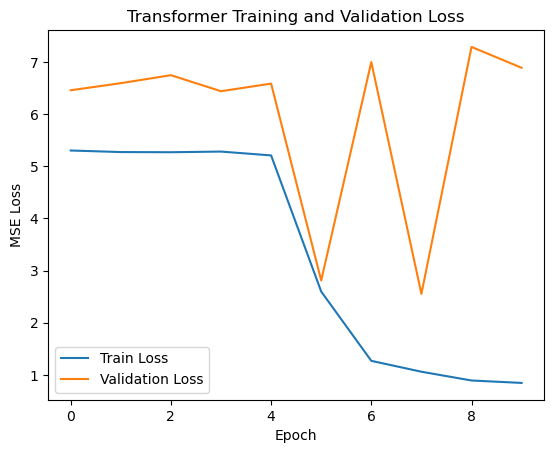

In [ ]:
# Plot Transformer training vs. validation loss curves for the same visual comparison
# used for the LSTM — helps identify overfitting or underfitting behaviour
plt.figure()
plt.plot(transformer_train_losses, label="Train Loss")
plt.plot(transformer_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
# Display the comparison table of all three baseline models
# (Finite Differencing, Linear Regression, ARIMA)
results_df

,Model,MAE,RMSE
0,Finite Differencing,0.173202,0.570875
1,Linear Regression,0.095513,0.258790
2,ARIMA,0.157347,0.184776


In [ ]:
# Display LSTM validation-set metrics (MAE and RMSE on the log-scale target)
lstm_results_df

,Model,MAE,RMSE
0,LSTM,2.352505,2.516392


In [ ]:
# Display Transformer validation-set metrics (MAE and RMSE on the log-scale target)
transformer_resuls_df

,Model,MAE,RMSE
0,Transformer,1.652459,2.627291
